In [79]:
import numpy as np

m = 400
rng = np.random.default_rng(seed=42)
X = rng.standard_normal((m, 1))
y = 4 + 3*X + rng.standard_normal((m, 1))

print(X.shape, y.shape)
X[:10]

(400, 1) (400, 1)


array([[ 0.30471708],
       [-1.03998411],
       [ 0.7504512 ],
       [ 0.94056472],
       [-1.95103519],
       [-1.30217951],
       [ 0.1278404 ],
       [-0.31624259],
       [-0.01680116],
       [-0.85304393]])

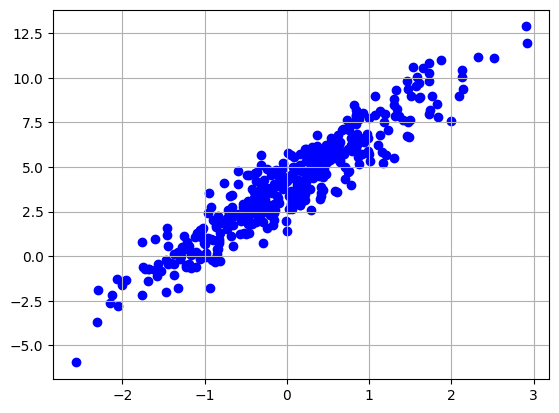

In [80]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(X, y, color="b", marker="o")
plt.grid(True)
plt.show()

In [81]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)
print(X_b.shape)
X_b[:10]

(400, 2)


array([[ 1.        ,  0.30471708],
       [ 1.        , -1.03998411],
       [ 1.        ,  0.7504512 ],
       [ 1.        ,  0.94056472],
       [ 1.        , -1.95103519],
       [ 1.        , -1.30217951],
       [ 1.        ,  0.1278404 ],
       [ 1.        , -0.31624259],
       [ 1.        , -0.01680116],
       [ 1.        , -0.85304393]])

[[3.94733716]
 [2.95482463]]
[[-4.92]
 [12.81]]


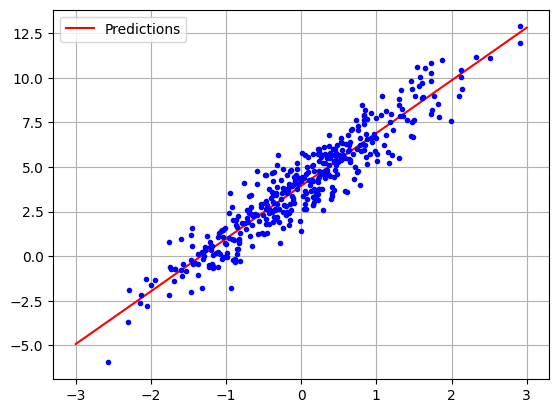

In [82]:
theta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y # normal equation
print(theta)

X_new = np.array([[-3], [3]])
X_new_b = add_dummy_feature(X_new)
y_pred = X_new_b @ theta
print(y_pred.round(2))

plt.plot(X_new, y_pred, "r-", label="Predictions")
plt.plot(X, y, "b.")
plt.legend()
plt.grid(True)
plt.show()

In [83]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X, y)

print(lr.intercept_) # bias
print(lr.coef_) # features weights

[3.94733716]
[[2.95482463]]


[[3.94733716]
 [2.95482463]]


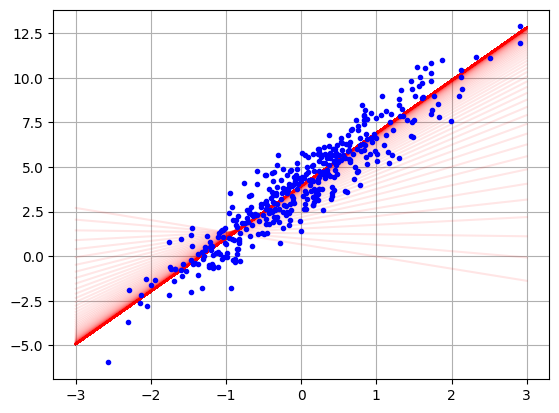

In [84]:
import numpy as np

n_epochs = 500
eta = 0.05 # lr
m = len(X_b)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1)) # se inicia de forma aleatoria

for i in range(n_epochs):
    theta = theta - eta * 2/m * X_b.T @ (X_b @ theta - y) 
    
    X_new = np.array([[-3], [3]])
    X_new_b = add_dummy_feature(X_new)
    
    y_pred = X_new_b @ theta
    plt.plot(X_new, y_pred, "r-", alpha=50/(i+n_epochs))

print(theta)

plt.plot(X, y, "b.")
plt.grid(True)
plt.show()

[[3.95124094]
 [2.96252872]]


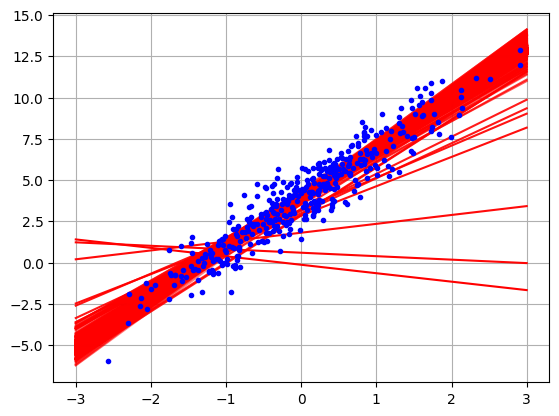

In [85]:
n_epochs = 50
t0, t1 = 5, 50

# learning schedule hyperparameters
def learning_schedule(t):
    return t0 / (t + t1)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1)) # randomly initialized model parameters

for epoch in range(n_epochs):
    # By convention iterate by rounds of m iterations; each round is called an epoch
    # Una época es un paso COMPLETO POR TODO el dataset
    for iteration in range(m):
        random_index = rng.integers(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi) # for SGD, do not divide by m
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

        X_new = np.array([[-3], [3]])
        X_new_b = add_dummy_feature(X_new)
    
        y_pred = X_new_b @ theta
        plt.plot(X_new, y_pred, "r-", alpha=50/(iteration+n_epochs))

print(theta)

plt.plot(X, y, "b.")
plt.grid(True)
plt.show()

In [86]:
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor()

sgd.fit(X, y.squeeze())

print(sgd.intercept_)
print(sgd.coef_)

[3.94846536]
[2.95150625]


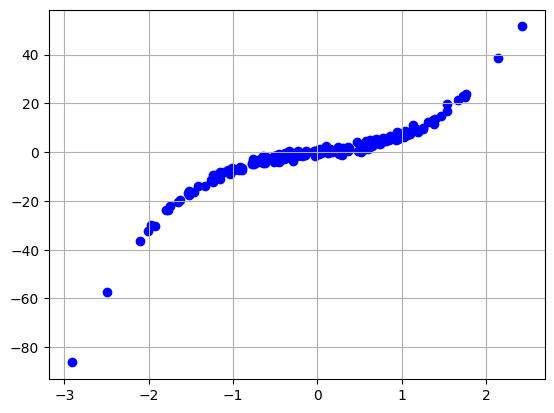

In [118]:
import numpy as np

m = 200
rng = np.random.default_rng()
X = rng.standard_normal((m, 1))
y = 3*(X**3) + 4*(X) + rng.standard_normal((m, 1))

import matplotlib.pyplot as plt

fig2, ax2 = plt.subplots()
ax2.scatter(X, y, color="b", marker="o")
plt.grid(True)
plt.show()

In [119]:
from sklearn.preprocessing import PolynomialFeatures

polf = PolynomialFeatures(degree=3, include_bias=False)
X_trans = polf.fit_transform(X)

print(X_trans.shape)
print(X[0])
print(X_trans[0])

(200, 3)
[-1.10239917]
[-1.10239917  1.21528394 -1.33972801]


In [124]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_trans, y)

print(lr.intercept_)
print(lr.coef_)

[-0.05468762]
[[ 4.07781121 -0.02747248  2.97702672]]


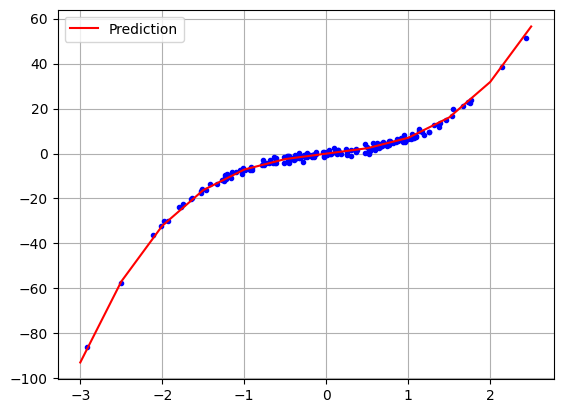

In [127]:
X_new = [[i/2] for i in range(-6, 6)]
y_new = lr.predict(polf.transform(X_new))

plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", label="Prediction")
plt.legend()
plt.grid(True)
plt.show()